## ATACseq Data with over 500k entries 

each row (=entry) is a OCR peak. The set tells us how strong the peak is in each of the 89 immune cell types  
The data also includes Metadata for each of those peaks:  

- **chrom**  
Chromosome on which the OCR is located  

- **Summit**  
Genomic coordinate of the "peak summit"  
--> position with the strongest ATACseq signal within the OCR  

- **mm10 cons_score**  
as in "evolutionary conservation score"  
--> functional importance (highest value = 1.00)  

- **-log10_bestPvalue**  
remember: p-value measures likelihood of the result being just background noise (small p-value --> likely not background noise)  
--> kleiner log, großer p-value, wahrscheinlich relevant

- **included in systematic analysis**  
Boolean / yes-no flag indicating whether the authors considered this OCR reliable enough for downstream analyses in the paper  

- **TSS**  
name of closest TSS gene

- **genes within 100kb**  
just lists all the genes in that range as str 


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from pathlib import Path
ATAC_path = Path('data') / 'ImmGenATAC18_AllOCRsInfo.csv'
ATAC_data = pd.read_csv(ATAC_path)

df = pd.read_csv("data/ImmGenATAC18_AllOCRsInfo.csv")
df.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_1,chr1,3020786,0.00,0.56,NaN,NaN,NaN,0.41,0.71,...,0.10,0.10,3.19,1.37,0.52,1.27,0.10,0.57,3.27,1.41
1,ImmGenATAC1219.peak_2,chr1,3087226,0.00,0.50,NaN,NaN,NaN,0.41,1.64,...,1.70,0.10,1.41,0.47,0.11,0.92,0.98,2.16,2.34,0.94
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50


<h1> ATAC_sequence Data_Clean_Up 
<h2> Handling Missing Values

In [4]:
missing_value = ATAC_data.isnull().sum()
ATAC_data.isnull().sum()[missing_value > 0]

Included.in.systematic.analysis    177716
TSS                                498303
genes.within.100Kb                  84885
dtype: int64

**Missing value handling**: <p>
Wir haben nur in drei Kategorien missing values (NAs). In allen drei Kategorien steht NA allerdings nicht für einen wirklich fehlenden Wert, sondern gibt uns echte Informationen. Die NAs *Included.in.systematic.analysis* geben uns zum Beispiel Aufschluss darüber, welche ATAC-peaks nicht in der späteren Analyse vom Research team weiterverwendet wurde.
Alle NAs in *TSS* markieren distal Enhancer und Gene, die in ihrer unmittelbaren Nähe (100kbs) kein Gen besitzen, werden ebenfalls mit NA gekennzeichnet. <p>
Daher müssen wir auch keine fehlenden Werte entfernen.

<h2> P-Value Filtering

In [5]:
Minimum_pvalue = ATAC_data['_-log10_bestPvalue'].min()
number_minimum = (ATAC_data['_-log10_bestPvalue'] == Minimum_pvalue).sum()
ATAC_data[ATAC_data['_-log10_bestPvalue'] == Minimum_pvalue]

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
64295,ImmGenATAC1219.peak_64296,chr10,122421608,0.0,0.0,NaN,NaN,Avpr1a,0.41,0.1,...,0.1,0.10,0.11,0.11,0.11,0.11,0.34,0.11,0.11,0.11
508409,ImmGenATAC1219.peak_508410,chrX,106733598,0.0,0.0,NaN,NaN,NaN,0.41,0.1,...,0.1,0.29,0.11,0.47,0.52,0.14,0.10,0.11,0.51,0.11


**P-Value filtering**: <p>
Wir filtern die Werte nach P-Values und untersuchen den Datensatz nach auffällig niedrigen vs hohen p-Values. <br> Eventuell sollten hohe p-Values (niedriger log) aus dem Datensatz rausgenommen werden. <br> Eventuell könnte man eine bestimmten p-Value Grenze setzen (z.B. 0.05) und dann Werte darüber excluden. <p>
*TO BE CONTINUED...*

<h2> Filtering low-signal peaks or low-variance features
<h3> Filtering low-signal peaks

In [6]:
ATAC_pfiltered = ATAC_data[ATAC_data['_-log10_bestPvalue'] > -np.log10(0.05)]
ATAC_pfiltered
#len(ATAC_pfiltered)

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
5,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,2.36,1.64,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
6,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.41,0.10,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512588,ImmGenATAC1219.peak_512589,chrY,90811728,0.00,2.33,1.0,NaN,Erdr1,0.41,7.41,...,4.98,4.47,2.83,4.93,4.92,5.13,9.13,2.21,6.53,6.11
512589,ImmGenATAC1219.peak_512590,chrY,90812084,0.00,3.12,1.0,NaN,Erdr1,2.36,8.79,...,4.03,4.07,5.87,5.36,3.99,7.12,3.57,2.64,5.59,3.64
512590,ImmGenATAC1219.peak_512591,chrY,90812450,0.00,3.99,1.0,NaN,Erdr1,4.37,8.79,...,3.81,3.34,4.27,6.73,5.53,7.21,5.96,5.17,6.53,6.11
512591,ImmGenATAC1219.peak_512592,chrY,90812906,0.00,3.21,1.0,NaN,Erdr1,0.41,7.41,...,4.28,5.55,4.15,6.88,7.16,6.21,8.75,6.83,8.14,4.64


**ATAC_data nur mit Werten, die einen p-Value kleiner 0.05 haben** <p>
1/3 von Werten haben einen p-Value der größer ist als 0.05, daher könnten diese Werte eine geringere statistische Signifikanz haben. Für unsere Nalyse ist es allerdings nicht sinnvoll, all diese Werte zu vernachlässigen.

In [7]:
ATAC_NA_pvalue = ATAC_data[
    (ATAC_data['_-log10_bestPvalue'] < -np.log10(0.05)) &
    (ATAC_data['Included.in.systematic.analysis'].isnull())
]

#Zeilen, die in Included.in.systematic.analysis NA stehen haben und gleichzeitig einen pValue von über 0.05 haben
# --> 150265 Werte (das entspricht allen Werten, deren p-Value über 0.05 ist)
# daher ist davon auszugehen, dass all diese Werte von Yoshida und Co. entfernt wurden (+noch mehr) 

len(ATAC_NA_pvalue)



150265

**Pre-Filtering im Yoshida Paper** <p>
Alle Werte, die einen p-Value von größer als 0.05 haben, wurden im Yoshida Paper auch von der Analyse ausgeschlossen (150265). Darüber hinaus haben Yoshida et al. noch weitere Werte nach eigenen bestimmten Kriterien Filering-Prozessen entfernt. Es würde für unsere Analyse daher Sinn ergeben, diesen Threshold von 0.05 anzuwenden, da diese Werte mindestens auch im Research von Paper von Yoshida entfernt wurden.


**Simons Zusatz:** <p>

- raw data (blacklist) anschauen & rausnehmen --> vielleicht included in pValue? müssen wir vergleichen
- Datensatz mal plotten (sollte normalverteilt sein)
- in GitHub Repo reinschauen (Fragen und so)

<h2> Blacklist Filtering:

In [8]:
from pathlib import Path
ATAC_path_blacklist = Path('data') / 'mm10.blacklist(2).bed'
ATAC_data_blacklist = pd.read_csv(ATAC_path_blacklist)

ATAC_data_blacklist
#df2.__len__()

,chr10\t3110060\t3110270
0,chr10\t22142530\t22142880
1,chr10\t22142830\t22143070
2,chr10\t58223870\t58224100
3,chr10\t58225260\t58225500
4,chr10\t58228320\t58228520
...,...
158,chr9\t3038050\t3038300
159,chr9\t24541940\t24542200
160,chr9\t35305120\t35305620
161,chr9\t110281190\t110281400


In [9]:
cols = [
    "gene_name",
    "transcript_name",
    "chrom",
    "strand",
    "txStart",
    "txEnd",
    "cdsStart",
    "cdsEnd",
    "exonCount",
    "exonStarts",
    "exonEnds"
]

ATAC_path_genanno = Path("data") / "Gene annotations.txt"

Gene_annotations = pd.read_csv(
    ATAC_path_genanno,
    sep="\t",
    names=cols
)

Gene_annotations.head()

,gene_name,transcript_name,chrom,strand,txStart,txEnd,cdsStart,cdsEnd,exonCount,exonStarts,exonEnds
0,Wdsub1,NM_001159636,chr2,-,59855193,59882606,59855270,59878527,11,"59855193,59858609,59861560,59862619,59862816,5...","59855275,59858750,59861737,59862726,59862857,5..."
1,Rbm18,NM_001159635,chr2,-,36116078,36136704,36117814,36134247,6,"36116078,36120812,36122851,36127214,36134134,3...","36117974,36120898,36122938,36127251,36134263,3..."
2,Prrc2b,NM_001159634,chr2,+,32151147,32234537,32182511,32230742,32,"32151147,32182457,32183122,32185344,32187480,3...","32151291,32182626,32183300,32185447,32187553,3..."
3,Ildr2,NM_001164528,chr1,+,166254138,166316832,166254375,166310795,10,"166254138,166269304,166270498,166291415,166294...","166254466,166269637,166270618,166291472,166294..."
4,Perm1,NM_172417,chr4,+,156215926,156221307,156217000,156220222,4,"156215926,156216716,156219740,156220109,","156215975,156219185,156219866,156221307,"


In [10]:
Gene_annotations[Gene_annotations["txStart"] == 59855193]
(Gene_annotations['txStart'] == 59855193).any #positiv Probe wird gefunden

<bound method Series.any of 0         True
1        False
2        False
3        False
4        False
         ...  
47377    False
47378    False
47379    False
47380    False
47381    False
Name: txStart, Length: 47382, dtype: bool>

In [11]:
Gene_annotations[Gene_annotations["txStart"] == 24541940]
#or
(Gene_annotations["txStart"] == 24541940).any() #Start von blacklisted Beispiel-gen ist nicht zu finden

np.False_

Wir haben die blacklisted Gene als Tabelle auslesen lassen und dann die Startnummern mit denen der annotierten Gene im Gene annotations Dataset verglichen. Die blacklisted Gene sind nicht im Gene annotations Dataset wiederzufinden, daher ist davon auszugehen, dass diese blacklisted Gene bereits zu Beginn des Data Cleanups von Yoshida et al. entfernt wurde.

<h2> Log-Transformation


In [12]:
log_ATAC_pfiltered = ATAC_pfiltered.copy()
log_ATAC_pfiltered.iloc[:,8:] = np.log1p(log_ATAC_pfiltered.iloc[:,8:])
log_ATAC_pfiltered.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,1.211941,0.095310,...,0.625938,0.431782,1.313724,0.667829,0.104360,4.164803,2.294553,0.845868,0.712950,0.104360
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.343590,0.095310,...,0.364643,1.040277,0.506818,0.104360,0.652325,2.674149,0.683097,0.824175,0.712950,0.104360
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.343590,0.095310,...,0.364643,0.095310,0.506818,1.026042,0.412110,0.652325,0.559616,0.845868,0.959350,1.704748
5,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,1.211941,0.970779,...,0.850151,0.254642,0.207014,0.636577,0.104360,0.425268,0.875469,0.641854,1.353255,2.311545
6,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.343590,0.095310,...,0.625938,1.075002,0.463734,0.104360,0.871293,1.275363,0.559616,1.193922,1.205971,2.486572


**Funktion zur log_transformation**
<p> Um bestimmte Datenanalyse Verfahren zu verwenden (Clustering, PCA, Regression) benötigt man einen normalverteilten Datensatz... Daher muss mit den ATAC-Daten eine log transformation durchgeführt werden


<h1> 1.2 Enhancer vs Promoter (Accessibility signatures)

<h2> Preparing promoter vs enhancer dataset 

In [13]:
ATAC_enhancers = ATAC_pfiltered[ATAC_pfiltered["TSS"].isnull()]
ATAC_enhancers

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
5,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,2.36,1.64,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
6,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.41,0.10,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512588,ImmGenATAC1219.peak_512589,chrY,90811728,0.00,2.33,1.0,NaN,Erdr1,0.41,7.41,...,4.98,4.47,2.83,4.93,4.92,5.13,9.13,2.21,6.53,6.11
512589,ImmGenATAC1219.peak_512590,chrY,90812084,0.00,3.12,1.0,NaN,Erdr1,2.36,8.79,...,4.03,4.07,5.87,5.36,3.99,7.12,3.57,2.64,5.59,3.64
512590,ImmGenATAC1219.peak_512591,chrY,90812450,0.00,3.99,1.0,NaN,Erdr1,4.37,8.79,...,3.81,3.34,4.27,6.73,5.53,7.21,5.96,5.17,6.53,6.11
512591,ImmGenATAC1219.peak_512592,chrY,90812906,0.00,3.21,1.0,NaN,Erdr1,0.41,7.41,...,4.28,5.55,4.15,6.88,7.16,6.21,8.75,6.83,8.14,4.64


In [14]:
ATAC_promoters = ATAC_pfiltered[-ATAC_pfiltered["TSS"].isnull()]
ATAC_promoters

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
20,ImmGenATAC1219.peak_21,chr1,3671437,0.72,2.02,1.0,Xkr4,Xkr4,0.41,3.68,...,2.53,0.10,0.11,1.87,0.92,4.97,2.62,2.64,2.83,17.14
139,ImmGenATAC1219.peak_140,chr1,4785675,0.41,15.87,1.0,Mrpl15,"Mrpl15,Lypla1,Tcea1",9.93,20.06,...,21.99,24.19,21.76,22.06,20.80,33.25,23.63,20.90,13.30,22.38
145,ImmGenATAC1219.peak_146,chr1,4807877,0.47,25.12,1.0,Lypla1,"Mrpl15,Lypla1,Tcea1",29.54,42.40,...,26.85,17.69,41.52,42.24,42.23,32.82,31.65,38.34,26.68,33.27
157,ImmGenATAC1219.peak_158,chr1,4857752,0.12,45.65,1.0,Tcea1,"Mrpl15,Lypla1,Tcea1",115.42,141.25,...,80.17,108.52,85.43,79.55,92.80,133.71,85.20,101.38,137.79,129.55
159,ImmGenATAC1219.peak_160,chr1,4858351,0.02,7.78,1.0,Tcea1,"Mrpl15,Lypla1,Tcea1",4.37,6.07,...,10.55,11.20,10.07,10.37,9.80,8.34,8.76,17.31,8.39,11.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512467,ImmGenATAC1219.peak_512468,chrX_GL456233_random,39222,0.32,73.75,1.0,Vamp7,"Vamp7,Spry3",57.63,42.40,...,37.95,58.81,61.00,38.21,37.03,63.17,48.63,61.16,82.32,48.00
512477,ImmGenATAC1219.peak_512478,chrX_GL456233_random,159627,0.12,16.28,1.0,Tmlhe,"Spry3,Tmlhe",22.66,21.83,...,3.12,2.21,9.63,0.47,1.75,16.68,8.32,13.71,29.25,5.34
512506,ImmGenATAC1219.peak_512507,chrY,1010556,0.18,13.45,1.0,Eif2s3y,"Eif2s3y,Tspy-ps",12.99,11.79,...,21.53,20.30,17.67,20.86,16.23,9.28,24.00,12.94,11.58,18.65
512522,ImmGenATAC1219.peak_512523,chrY,1245808,0.18,18.59,1.0,Uty,"Uty,Ddx3y",19.40,25.33,...,34.26,34.61,21.57,23.95,24.12,30.97,36.01,30.23,38.30,35.58


<h2> Calculating mean and median values (promoter vs enhancer)

In [15]:
mean_promoters = ATAC_promoters.iloc[:,8:].mean(axis=1) #Mittelwert jedem Signalpeak über alle Zellen hinweg
mean_promoters.mean() #


np.float64(26.801848038378665)

In [16]:
median_promoters = ATAC_promoters.iloc[:,8:].median(axis=1) #Mittelwert jedem Signalpeak über alle Zellen hinweg
median_promoters.median() #

np.float64(16.315)

In [17]:
mean_enhancers = ATAC_enhancers.iloc[:,8:].mean(axis=1)
mean_enhancers.mean()

np.float64(4.241589833922086)

In [18]:
median_enhancers = ATAC_enhancers.iloc[:,8:].median(axis=1)
median_enhancers.median()

np.float64(1.455)

**Mean ATAC readout signal: Enhancers vs promoters** <p>
The signal peaks that were identified as promoters/TSS show a way higher mean signal across all celltypes than the enhancers (26.801848038378665 vs 4.241589833922086). The median shows a similar trend. To proof whether the mean or the median are more accurate, one needs to take a look at promoter vs enhancer signal distributions and things such as the standard derivation and variance.

<h2> Plotting enhancer vs promoter

<Axes: xlabel='DC.4+.Sp', ylabel='Count'>

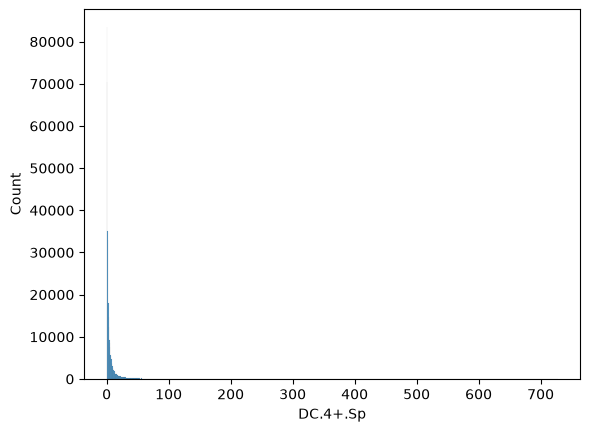

In [19]:
sns.histplot(data=ATAC_pfiltered.iloc[:,8:], x= "DC.4+.Sp" )

<Axes: xlabel='DC.4+.Sp', ylabel='Count'>

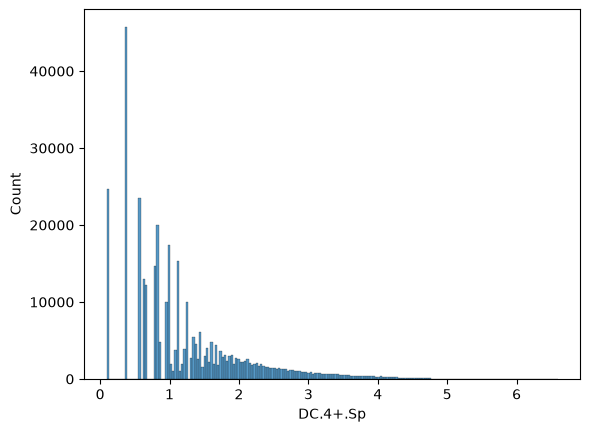

In [20]:
sns.histplot(data=log_ATAC_pfiltered.iloc[:,8:], x= "DC.4+.Sp" )

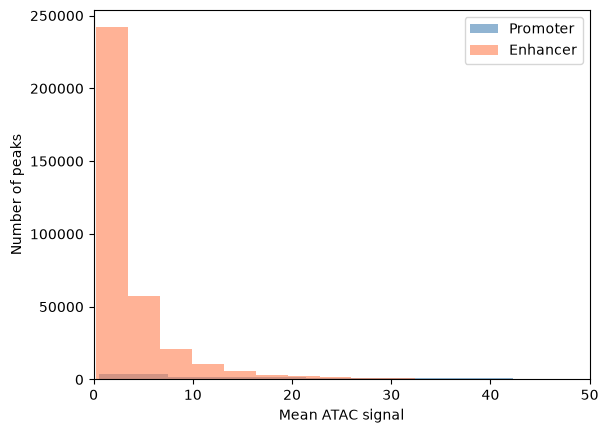

In [21]:
plt.hist(mean_promoters, bins=100, alpha=0.6, label='Promoter', color='steelblue')
plt.hist(mean_enhancers, bins=100, alpha=0.6, label='Enhancer', color='coral')
plt.xlim(0, 50) 
plt.xlabel('Mean ATAC signal')
plt.ylabel('Number of peaks')
plt.legend()

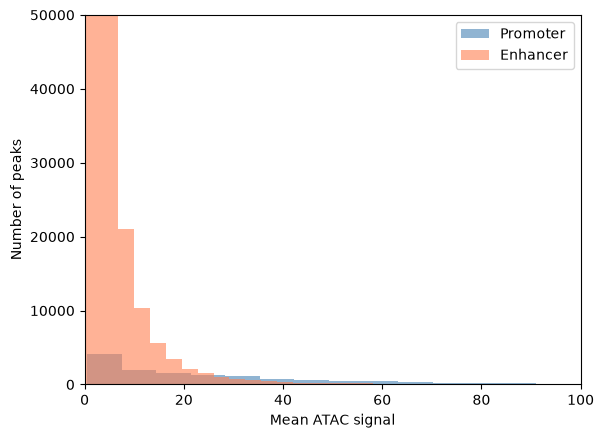

In [22]:
plt.hist(mean_promoters, bins=100, alpha=0.6, label='Promoter', color='steelblue')
plt.hist(mean_enhancers, bins=100, alpha=0.6, label='Enhancer', color='coral')
plt.xlim(0, 100) 
plt.ylim(0, 50000)
plt.xlabel('Mean ATAC signal')
plt.ylabel('Number of peaks')
plt.legend()

In [23]:
ATAC_pfiltered_extended = ATAC_pfiltered.copy() 
#ich erstelle mir einen erweiterten Datensatz, der neben dem normalen ATAC_pfiltered dataframe 
#noch weitere spalten mit den means, medians, stds und cvs enthält...
ATAC_pfiltered_extended["mean_signal"] = ATAC_pfiltered.iloc[:,8:].mean(axis=1)
ATAC_pfiltered_extended["median_signal"] = ATAC_pfiltered.iloc[:,8:].median(axis=1)
ATAC_pfiltered_extended["std_signal"] = ATAC_pfiltered.iloc[:,8:].std(axis=1)
ATAC_pfiltered_extended["cv_signal"] = ATAC_pfiltered_extended["std_signal"]/ATAC_pfiltered_extended["mean_signal"]

ATAC_pfiltered_extended["peak_type"] = np.where(
    ATAC_pfiltered_extended["TSS"].notna(), "Promoter", "Enhancer"
)
ATAC_pfiltered_extended[["peak_type", "mean_signal", "median_signal", "std_signal", "cv_signal"]]


,peak_type,mean_signal,median_signal,std_signal,cv_signal
2,Enhancer,1.521000,0.495,6.716484,4.415834
3,Enhancer,0.874556,0.530,1.533709,1.753701
4,Enhancer,0.882111,0.630,0.816587,0.925719
5,Enhancer,1.096556,0.785,1.218798,1.111478
6,Enhancer,0.944556,0.680,1.262417,1.336520
...,...,...,...,...,...
512588,Enhancer,5.823889,4.955,3.648828,0.626528
512589,Enhancer,5.526444,4.705,4.053177,0.733415
512590,Enhancer,6.936111,5.775,4.887909,0.704705
512591,Enhancer,6.995111,6.440,4.386282,0.627050


Text(0.5, 1.0, 'CV of Signal')

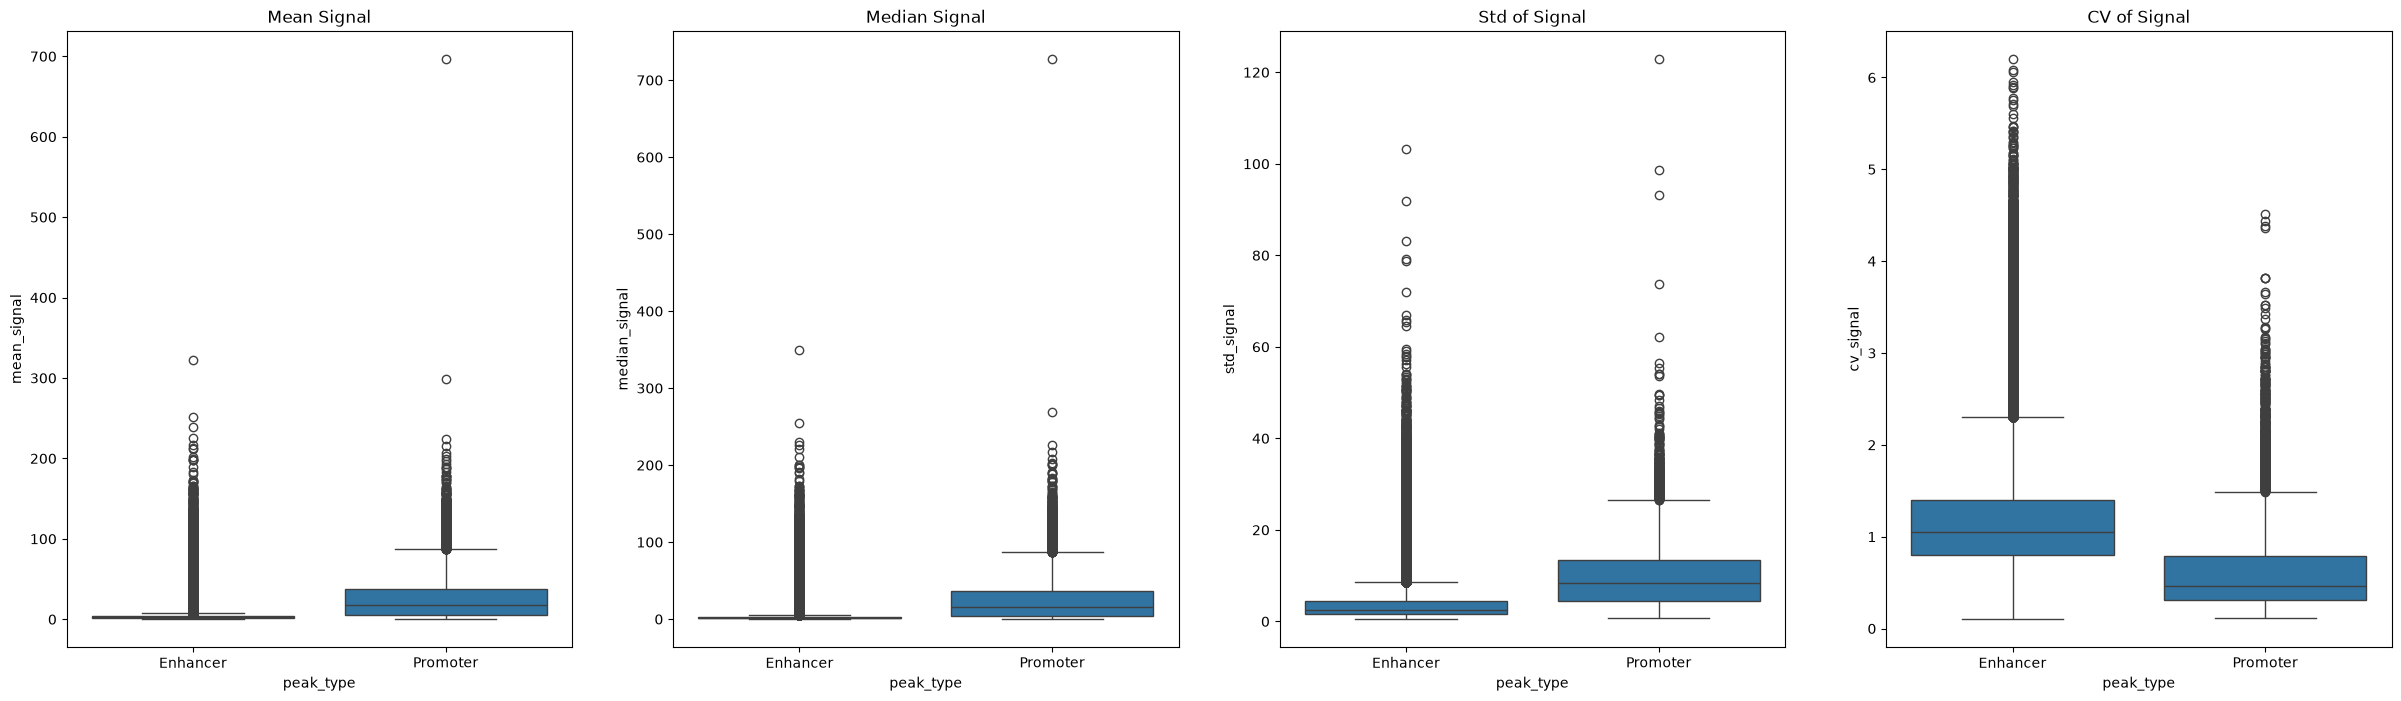

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(30, 8))
sns.boxplot(data=ATAC_pfiltered_extended, x="peak_type", y="mean_signal", ax=axes[0])
axes[0].set_title("Mean Signal")
sns.boxplot(data=ATAC_pfiltered_extended, x="peak_type", y="median_signal", ax=axes[1])
axes[1].set_title("Median Signal")
sns.boxplot(data=ATAC_pfiltered_extended, x="peak_type", y="std_signal", ax=axes[2])
axes[2].set_title("Std of Signal")
sns.boxplot(data=ATAC_pfiltered_extended, x="peak_type", y="cv_signal",  ax=axes[3])
axes[3].set_title("CV of Signal")

<h2> Calculating Std and Variance (promoter vs enhancer)

In [25]:
std_promoters = ATAC_promoters.iloc[:,8:].std(axis=1) #Mittelwert jedem Signalpeak über alle Zellen hinweg
std_promoters.mean()

np.float64(9.735575860075166)

In [26]:
std_enhancers = ATAC_enhancers.iloc[:,8:].std(axis=1) #Mittelwert jedem Signalpeak über alle Zellen hinweg
std_enhancers.mean()

np.float64(3.8733624583869357)

In [27]:
var_promoters = ATAC_promoters.iloc[:,8:].var(axis=1) #Mittelwert jedem Signalpeak über alle Zellen hinweg
var_promoters.mean()

np.float64(143.22016480984846)

In [28]:
var_enhancers = ATAC_enhancers.iloc[:,8:].var(axis=1) #Mittelwert jedem Signalpeak über alle Zellen hinweg
var_enhancers.mean()

np.float64(30.960503552413734)

In [29]:
cv_enhancers = std_enhancers / mean_enhancers #Mittelwert jedem Signalpeak über alle Zellen hinweg
cv_enhancers.mean()

np.float64(1.1584095067846003)

In [30]:
cv_promoters = std_promoters / mean_promoters #Mittelwert jedem Signalpeak über alle Zellen hinweg
cv_promoters.mean()

np.float64(0.6224775768891224)

**Ohne Log-Transformation: verzerrte, nicht-vergleichbare Werte bei der Std (und dann auch bei Variance)** <p>
Promoter werden in allen zelltypen eher häufiger ausgelesen als enhancer, weil sie konstitutiv offen sind, enhancer sind eher entweder offen oder gecshlossen (ausgelesen oder nicht ausgelesen).... Daher sollten Enhancer eine größer standardabweichung haben, weil enhancer halt entweder 0 oder viel abgelesen werden während promoter im durschnitt eher gleich häufig in zellen ausgelesen werden --> Enhancer sind ja viel mehr zelltyp spezifisch... <br> Der kleinere std-Werte bei enhancer hier liegt daran, dass wir keine log transformation gemacht haben. Enhancer haben an und für sich einfach kleinere ATAC signals werte,dadurch einfach per default kleinere werte für die std.

**ABER: CV (Coefficient of Variation) ist aussagekräftig** <p>
Da der CV das Verhältnis zwischen std und mean berechnt, kann man anhand von diesem wert gut sehen, wie sehr ENhancer vs Promoter abweichen. Den Erwartungen entsprechend schwanken die Enhancer Werte deutlich mehr als die Promoter Werte.

<b> Notiz an mich: 
+ nochmal bitte nur mit unseren Zellen machen
+ Var und Std nochmal mit Z-Transformation

## 2.3 CRE–Gene Association via Correlation

<b> Linking ATAC-seq peaks (our T-cels gd) to genes via Correlation

Idee: Nur peaks raussuchen, die in 100kb ein Gen haben (Spalte: genes within 100kb). Dann Signalpeak/Genpaare identifizieren. Für ATAC-Datensatz die Signalpeaks über die Zelltypen in einen Vektor packen. Für RNA-Datensatz die Genexpression von dem Gen über die Zelltypen in einen anderen Vektor... Dann Korrelation zwischen Signal peak (ATAC) und Genexpression (RNA)

In [31]:
ATAC_path_Tgd = Path('data') / 'ATAC_seq_gd_anot.csv'
ATAC_Tgd = pd.read_csv(ATAC_path_Tgd)
ATAC_Tgd.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,MPP4.135+.BM,preT.DN1.Th,...,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
0,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,0.11,0.40,...,0.11,0.10,0.35,0.11,0.76,0.53,1.46,0.11,0.12,0.86
1,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.11,0.46,...,0.47,0.10,0.58,0.11,0.29,0.53,0.51,0.11,0.70,0.13
2,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.11,0.77,...,1.34,1.69,0.34,1.39,1.58,3.16,0.51,0.99,0.12,0.73
3,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,1.58,0.77,...,0.47,1.02,0.10,1.33,0.10,1.48,0.15,0.11,1.26,0.73
4,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.11,0.40,...,0.47,0.10,0.58,1.33,1.27,1.11,0.51,2.86,0.70,0.73


In [33]:
ATAC_Tgd[-(ATAC_Tgd["genes.within.100Kb"].isnull())]


,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,MPP4.135+.BM,preT.DN1.Th,...,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
11,ImmGenATAC1219.peak_18,chr1,3611363,0.16,3.32,1.0,NaN,Xkr4,0.11,0.11,...,0.87,1.02,0.58,0.40,0.41,0.53,0.51,0.11,1.95,0.73
12,ImmGenATAC1219.peak_19,chr1,3670859,0.76,1.74,1.0,NaN,Xkr4,3.04,4.73,...,2.82,6.59,2.69,1.33,3.82,2.35,1.29,0.99,1.39,3.33
13,ImmGenATAC1219.peak_20,chr1,3671114,0.94,2.02,1.0,NaN,Xkr4,4.84,4.73,...,4.73,5.18,4.47,0.54,2.72,1.48,1.29,0.99,0.68,2.60
14,ImmGenATAC1219.peak_21,chr1,3671437,0.72,2.02,1.0,Xkr4,Xkr4,4.84,2.48,...,3.14,2.29,6.44,0.84,2.69,1.11,4.59,3.12,2.96,0.13
15,ImmGenATAC1219.peak_22,chr1,3671783,0.91,9.67,1.0,NaN,Xkr4,2.58,1.80,...,3.71,3.07,2.76,0.11,2.58,0.97,1.04,2.23,1.33,0.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362325,ImmGenATAC1219.peak_512589,chrY,90811728,0.00,2.33,1.0,NaN,Erdr1,3.49,2.09,...,4.17,7.10,6.93,9.58,9.65,11.37,3.98,15.78,5.85,19.30
362326,ImmGenATAC1219.peak_512590,chrY,90812084,0.00,3.12,1.0,NaN,Erdr1,2.15,1.76,...,2.55,4.00,10.15,6.88,20.55,8.96,2.34,10.00,9.77,10.93
362327,ImmGenATAC1219.peak_512591,chrY,90812450,0.00,3.99,1.0,NaN,Erdr1,2.58,3.32,...,3.37,4.55,8.41,8.61,19.64,8.96,3.61,13.42,14.05,9.01
362328,ImmGenATAC1219.peak_512592,chrY,90812906,0.00,3.21,1.0,NaN,Erdr1,3.04,3.56,...,8.18,10.40,15.50,12.38,15.54,10.92,3.52,11.73,8.31,12.91


In [ ]:
import scipy.stats as stats
RNA_seq = pd.read_csv('data/mmc2.csv')

meta_cols = ["TSS", "genes.within.100Kb"]  
signal_cols = [col for col in ATAC_Tgd.columns if col not in meta_cols]

results = []

for peak_id, row in ATAC_Tgd[ATAC_Tgd["genes.within.100Kb"].notna()].iterrows():
    peak_signal = row[signal_cols]  # Vektor über alle Zelltypen
    
    gene = row["genes.within.100Kb"]  # Genname(n)
    
    # Falls mehrere Gene in der Zelle stehen (z.B. "Cd19,Pax5")
    for gene_name in str(gene).split(","):
        gene_name = gene_name.strip()
        
        if gene_name in RNA_seq.index:
            gene_expr = RNA_seq.loc[gene_name, signal_cols]
            
            r, p = stats.pearsonr(peak_signal, gene_expr)
            
            results.append({
                "peak_id": peak_id,
                "gene": gene_name,
                "r": r,
                "p_value": p
            })

results_corr = pd.DataFrame(results)
results_corr.head()

""
